# SafeCross AI
## Notebook 01: Real Data Acquisition, Cleaning, and Initial Integration

**Student:** Joey Wu-Oswald  
**Project:** SafeCross AI  
**Purpose:** Build the first reproducible dataset for predicting and explaining road-safety risk in New York City.

---

### What this notebook does

This notebook uses **real public data** to:

1. Download **every** motor-vehicle crash record in the selected scope (default: all five boroughs, no row cap) from **NYC Open Data**, and verify the download against the server's own row count.
2. Clean dates, times, coordinates, and injury fields.
3. Download a drivable street network from **OpenStreetMap** using OSMnx.
4. Match each crash to the nearest road segment and street-network node.
5. Download historical hourly weather data using **Meteostat**.
6. Merge crash, street-layout, and weather information.
7. Save clean intermediate files for later exploratory analysis and modeling.

### What this notebook does *not* do

This notebook does **not** train a machine-learning model. It also does not yet create non-crash comparison examples. Those are important tasks, but they should happen only after the real data pipeline has been checked carefully.

The next notebook should define the prediction unit and target. A likely MVP is an **intersection or road-segment risk table**, rather than treating each crash record as an independent prediction example.

## Data sources and attribution

| Source | Role in SafeCross AI | Official reference |
|---|---|---|
| NYC Open Data, Motor Vehicle Collisions: Crashes | Crash date, time, coordinates, injuries, fatalities, and contributing factors | https://data.cityofnewyork.us/Public-Safety/Motor-Vehicle-Collisions-Crashes/h9gi-nx95 |
| OpenStreetMap through OSMnx | Street geometry and road attributes such as road class, lanes, speed tags, and one-way status | https://osmnx.readthedocs.io/en/stable/ |
| Meteostat | Historical hourly weather observations assembled from public providers, including government weather services | https://dev.meteostat.net/python/ |

**OpenStreetMap attribution:** © OpenStreetMap contributors. See https://www.openstreetmap.org/copyright.

### Responsible-use reminder

A model built from police-reported crash data describes patterns in the available records. It does not prove that a road feature *caused* a crash. Reporting practices, missing coordinates, traffic volume, construction, enforcement, and many other factors can affect the dataset. SafeCross AI should present results as decision-support evidence, not as a replacement for transportation engineers or safety authorities.

## Suggested repository structure

Run this notebook from either the repository root or the `notebooks/` folder.

```text
SafeCross-AI/
├── data/
│   ├── raw/          # Unmodified downloaded data
│   ├── interim/      # Cleaned or partially merged data
│   └── processed/    # Final modeling tables
├── notebooks/
│   └── 01_data_acquisition_and_cleaning.ipynb
├── reports/
│   └── figures/
├── src/
├── README.md
├── requirements.txt
└── .gitignore
```

Large downloaded files normally should not be committed to GitHub. The code, source links, and instructions should be committed so another person can reproduce them.

# 1. Environment setup

The next cell installs the packages used in this notebook.

- `pandas` and `numpy` handle tables and numerical values.
- `requests` downloads NYC Open Data through its API.
- `geopandas` and `shapely` handle geographic points and road geometries.
- `osmnx` downloads and analyzes OpenStreetMap street networks.
- `meteostat` retrieves historical weather records.
- `matplotlib` creates basic quality-control plots.
- `pyarrow` allows us to save efficient Parquet files.

Run the installation cell once in a new environment. After installation, restart the kernel if Jupyter asks you to do so.

In [1]:
%pip install -q pandas numpy requests matplotlib geopandas shapely osmnx meteostat pyarrow

Note: you may need to restart the kernel to use updated packages.


## Import the libraries

This cell imports the tools we will use and prints key package versions. Recording versions is part of reproducible research because geospatial libraries can change their APIs over time.

In [2]:
from __future__ import annotations

import os
import re
import sys
import warnings
from datetime import datetime, timedelta
from pathlib import Path
from typing import Any

import geopandas as gpd
import matplotlib.pyplot as plt
import meteostat as ms
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)
print("OSMnx:", ox.__version__)
print("Meteostat:", getattr(ms, "__version__", "version not exposed"))

Python: 3.12.0
pandas: 3.0.5
GeoPandas: 1.1.4
OSMnx: 2.1.1
Meteostat: 2.1.5


## Project configuration

This is the main cell Joey should edit when changing the study.

The default configuration now covers **the entire NYC crash dataset**:

- **All five boroughs** (`BOROUGH = "ALL"`), including crashes whose `borough` field is blank in the source data (a large share of NYC records have coordinates but no borough label, so filtering on borough would silently drop them)
- **From `2012-07-01`**, when the dataset begins, **to the latest date that is safely complete** (`END_DATE = "auto"`, explained below)
- **No row cap** (`MAX_CRASH_ROWS = None`). The notebook downloads every matching row and then checks the count against the server.

### Why the end date is automatic

Notebook 2 treats any intersection-week without a crash row as "zero crashes". That is only valid for weeks the crash table actually covers. NYC publishes crashes with a lag, and records for recent weeks keep arriving after the fact. If the weather file extended past the point where crash data is complete, the final weeks would look artificially crash-free, which would bias the test period. With `END_DATE = "auto"` the notebook asks the server for the most recent crash date and backs off by `END_DATE_SAFETY_DAYS` (30). You can instead set `END_DATE` to a fixed `"YYYY-MM-DD"`.

### Data-quality note for older years

Early records (2012 onward) were collected under different reporting practices, and a smaller share of them have usable coordinates. The number of crashes that can be placed on a street therefore changes over time. Notebook 2 splits chronologically, so the final weeks used for testing are the most recent ones. To start later, change `START_DATE` (for example `"2016-01-01"`) and the rest of the pipeline adapts.

To use a single borough or a shorter period, set `BOROUGH` and the dates accordingly.

`REFRESH_* = False` means the notebook will reuse a saved local file when available. Output file names include the scope and dates, so a previous Manhattan or 2024-only cache is not picked up. Set a refresh flag to `True` only when you intentionally want to download the source again.

In [3]:
# "ALL" = every NYC borough (plus rows whose borough field is blank).
# Or set a single borough: "MANHATTAN", "BROOKLYN", "QUEENS", "BRONX", "STATEN ISLAND".
BOROUGH = "ALL"
START_DATE = "2012-07-01"          # the NYC crash table begins in July 2012
END_DATE = "auto"                  # "auto" = latest crash date on the server minus END_DATE_SAFETY_DAYS
END_DATE_SAFETY_DAYS = 30          # recent weeks are still being filled in; stay clear of them
MAX_CRASH_ROWS = None  # None = download every matching row (no cap)

PLACE_QUERY_BY_BOROUGH = {
    "MANHATTAN": "Manhattan, New York City, New York, USA",
    "BROOKLYN": "Brooklyn, New York City, New York, USA",
    "QUEENS": "Queens, New York City, New York, USA",
    "BRONX": "The Bronx, New York City, New York, USA",
    "STATEN ISLAND": "Staten Island, New York City, New York, USA",
}

# One representative weather point per scope. For the whole city we use Central Park.
WEATHER_POINT_BY_BOROUGH = {
    "ALL": (40.7831, -73.9712, 10),
    "MANHATTAN": (40.7831, -73.9712, 10),
    "BROOKLYN": (40.6782, -73.9442, 15),
    "QUEENS": (40.7282, -73.7949, 15),
    "BRONX": (40.8448, -73.8648, 20),
    "STATEN ISLAND": (40.5795, -74.1502, 25),
}

BOROUGH = BOROUGH.upper()
if BOROUGH == "ALL":
    # OSMnx accepts a list of place queries and builds one network from their union.
    PLACE_QUERY = list(PLACE_QUERY_BY_BOROUGH.values())
    SCOPE_LABEL = "nyc_all"
else:
    PLACE_QUERY = PLACE_QUERY_BY_BOROUGH[BOROUGH]
    SCOPE_LABEL = BOROUGH.lower().replace(" ", "_")

WEATHER_LAT, WEATHER_LON, WEATHER_ELEVATION_M = WEATHER_POINT_BY_BOROUGH[BOROUGH]

REFRESH_CRASH_DATA = False
REFRESH_OSM_DATA = False
REFRESH_WEATHER_DATA = False

SOCRATA_APP_TOKEN = os.getenv("SOCRATA_APP_TOKEN")

if END_DATE == "auto":
    import requests, pandas as pd  # (imported again here so this cell can run on its own)
    _headers = {"User-Agent": "SafeCrossAI-StudentResearch/1.0"}
    if SOCRATA_APP_TOKEN:
        _headers["X-App-Token"] = SOCRATA_APP_TOKEN
    _response = requests.get(
        "https://data.cityofnewyork.us/resource/h9gi-nx95.json",
        params={"$select": "max(crash_date)"}, headers=_headers, timeout=120,
    )
    _response.raise_for_status()
    _latest = pd.Timestamp(next(iter(_response.json()[0].values())))
    END_DATE = (_latest - pd.Timedelta(days=END_DATE_SAFETY_DAYS)).strftime("%Y-%m-%d")
    print(f"Latest crash date on the server: {_latest.date()}  ->  END_DATE set to {END_DATE}")

print(f"Study area: {BOROUGH}  (scope label: {SCOPE_LABEL})")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Row cap: {'none' if MAX_CRASH_ROWS is None else f'{MAX_CRASH_ROWS:,}'}")
print(f"OpenStreetMap place query: {PLACE_QUERY}")


Latest crash date on the server: 2026-06-11  ->  END_DATE set to 2026-05-12
Study area: ALL  (scope label: nyc_all)
Date range: 2012-07-01 to 2026-05-12
Row cap: none
OpenStreetMap place query: ['Manhattan, New York City, New York, USA', 'Brooklyn, New York City, New York, USA', 'Queens, New York City, New York, USA', 'The Bronx, New York City, New York, USA', 'Staten Island, New York City, New York, USA']


## Create project folders

The following cell detects whether the notebook is running from the repository root or from a `notebooks/` folder. It then creates the data and figure directories if they do not exist.

This avoids hard-coding Joey's personal computer path into the notebook.

In [4]:
CURRENT_DIR = Path.cwd()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

DATA_RAW_DIR = REPO_ROOT / "data" / "raw"
DATA_INTERIM_DIR = REPO_ROOT / "data" / "interim"
DATA_PROCESSED_DIR = REPO_ROOT / "data" / "processed"
FIGURE_DIR = REPO_ROOT / "reports" / "figures"

for directory in [DATA_RAW_DIR, DATA_INTERIM_DIR, DATA_PROCESSED_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

CRASH_RAW_PATH = DATA_RAW_DIR / f"nyc_crashes_{SCOPE_LABEL}_{START_DATE}_{END_DATE}.csv"
CRASH_CLEAN_PATH = DATA_INTERIM_DIR / "crashes_clean.parquet"
OSM_GRAPH_PATH = DATA_RAW_DIR / f"osm_drive_{SCOPE_LABEL}.graphml"
WEATHER_RAW_PATH = DATA_RAW_DIR / f"weather_hourly_{SCOPE_LABEL}_{START_DATE}_{END_DATE}.csv"
STREET_MATCH_PATH = DATA_INTERIM_DIR / "crashes_with_street_features.parquet"
FINAL_DATA_PATH = DATA_PROCESSED_DIR / f"safecross_event_level_dataset_{SCOPE_LABEL}.parquet"

print("Repository root:", REPO_ROOT.resolve())
print("Raw data folder:", DATA_RAW_DIR.resolve())
print("Final dataset path:", FINAL_DATA_PATH.resolve())

Repository root: C:\Users\j9936\Desktop\Capstone\noteboooks
Raw data folder: C:\Users\j9936\Desktop\Capstone\noteboooks\data\raw
Final dataset path: C:\Users\j9936\Desktop\Capstone\noteboooks\data\processed\safecross_event_level_dataset_nyc_all.parquet


# 3. Download NYC crash records

NYC Open Data is hosted on a platform that supports the Socrata Open Data API. The helper functions below send a filtered query for the selected scope and date range.

The downloader:

1. Requests only the columns needed for the project.
2. **Asks the server how many rows match the query first**, using `count(*)`.
3. Downloads data in pages of up to 50,000 rows (the Socrata per-request maximum).
4. Retries temporary connection errors.
5. Applies a row cap only if `MAX_CRASH_ROWS` is a number. The default is `None`, meaning no cap.
6. Uses an optional application token when one is available. For a citywide download a free token is recommended because anonymous requests are throttled more aggressively: https://dev.socrata.com/docs/app-tokens.html

When `BOROUGH = "ALL"` there is **no borough filter at all**. This matters because many NYC crash records have valid coordinates but a blank `borough`. Filtering on `borough = 'MANHATTAN'` (or even on all five names) would drop those rows.

In [5]:
NYC_CRASH_ENDPOINT = "https://data.cityofnewyork.us/resource/h9gi-nx95.json"

CRASH_COLUMNS = [
    "crash_date", "crash_time", "borough", "zip_code", "latitude", "longitude",
    "on_street_name", "cross_street_name", "off_street_name",
    "number_of_persons_injured", "number_of_persons_killed",
    "number_of_pedestrians_injured", "number_of_pedestrians_killed",
    "number_of_cyclist_injured", "number_of_cyclist_killed",
    "number_of_motorist_injured", "number_of_motorist_killed",
    "contributing_factor_vehicle_1", "contributing_factor_vehicle_2",
    "vehicle_type_code1", "vehicle_type_code2", "collision_id",
]

def make_retrying_session() -> requests.Session:
    retry_policy = Retry(
        total=5,
        backoff_factor=1.0,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    session = requests.Session()
    session.mount("https://", HTTPAdapter(max_retries=retry_policy))
    session.headers.update({"User-Agent": "SafeCrossAI-StudentResearch/1.0"})
    if SOCRATA_APP_TOKEN:
        session.headers.update({"X-App-Token": SOCRATA_APP_TOKEN})
    return session

def build_where_clause(borough: str, start_date: str, end_date: str) -> str:
    clauses = [
        f"crash_date between '{start_date}T00:00:00.000' and '{end_date}T23:59:59.999'",
        "latitude IS NOT NULL",
        "longitude IS NOT NULL",
    ]
    # "ALL" deliberately adds no borough filter, so rows with a blank borough are kept.
    if borough != "ALL":
        clauses.append(f"borough = '{borough}'")
    return " AND ".join(clauses)

def fetch_expected_count(endpoint: str, borough: str, start_date: str, end_date: str) -> int:
    """Ask the server how many rows match the query, so we can verify completeness."""
    session = make_retrying_session()
    params = {"$select": "count(*)", "$where": build_where_clause(borough, start_date, end_date)}
    response = session.get(endpoint, params=params, timeout=120)
    response.raise_for_status()
    return int(next(iter(response.json()[0].values())))

def fetch_nyc_crashes(
    endpoint: str,
    borough: str,
    start_date: str,
    end_date: str,
    columns: list[str],
    max_rows: int | None = None,
    page_size: int = 50_000,
) -> pd.DataFrame:
    where_clause = build_where_clause(borough, start_date, end_date)
    session = make_retrying_session()
    records: list[dict[str, Any]] = []
    offset = 0

    while max_rows is None or len(records) < max_rows:
        current_limit = page_size if max_rows is None else min(page_size, max_rows - len(records))
        params = {
            "$select": ",".join(columns),
            "$where": where_clause,
            # A total order is required so offset paging never skips or repeats rows.
            "$order": "crash_date ASC, crash_time ASC, collision_id ASC",
            "$limit": current_limit,
            "$offset": offset,
        }
        response = session.get(endpoint, params=params, timeout=300)
        response.raise_for_status()
        page = response.json()
        if not page:
            break
        records.extend(page)
        print(f"Downloaded {len(records):,} rows...")
        if len(page) < current_limit:
            break
        offset += len(page)

    if max_rows is not None and len(records) == max_rows:
        print(
            "Warning: the configured row limit was reached. "
            "Set MAX_CRASH_ROWS = None to download every matching row."
        )
    return pd.DataFrame.from_records(records)


## Load from cache or download fresh crash data

If a raw CSV already exists and `REFRESH_CRASH_DATA` is `False`, the notebook reads the saved file. Otherwise, it calls the API and saves the exact downloaded response.

When no row cap is set, the notebook also compares the number of rows it has against the server's `count(*)` for the same query. A fresh download that does not match raises an error. A cached file that does not match prints a warning (the source table is updated over time, so a small difference can be legitimate; a large one usually means the cache was built with an old cap or scope).

Keeping a raw copy is important because we should always be able to distinguish the source data from our cleaned version.

In [6]:
expected_row_count = None
if MAX_CRASH_ROWS is None:
    try:
        expected_row_count = fetch_expected_count(
            NYC_CRASH_ENDPOINT, BOROUGH, START_DATE, END_DATE
        )
        print(f"Server reports {expected_row_count:,} matching rows.")
    except Exception as error:  # network problems should not block a cached run
        print("Could not fetch the expected row count:", error)

downloaded_fresh = False
if CRASH_RAW_PATH.exists() and not REFRESH_CRASH_DATA:
    crashes_raw = pd.read_csv(CRASH_RAW_PATH, dtype=str)
    print(f"Loaded cached crash file: {CRASH_RAW_PATH}")
else:
    crashes_raw = fetch_nyc_crashes(
        endpoint=NYC_CRASH_ENDPOINT,
        borough=BOROUGH,
        start_date=START_DATE,
        end_date=END_DATE,
        columns=CRASH_COLUMNS,
        max_rows=MAX_CRASH_ROWS,
    )
    crashes_raw.to_csv(CRASH_RAW_PATH, index=False)
    downloaded_fresh = True
    print(f"Saved raw crash file: {CRASH_RAW_PATH}")

print("Raw shape:", crashes_raw.shape)

# Completeness check against the server's own count.
if expected_row_count is not None:
    if len(crashes_raw) == expected_row_count:
        print(f"Completeness check passed: {len(crashes_raw):,} rows == server count.")
    elif downloaded_fresh:
        raise AssertionError(
            f"Downloaded {len(crashes_raw):,} rows but the server reports {expected_row_count:,}."
        )
    else:
        print(
            f"WARNING: cached file has {len(crashes_raw):,} rows but the server reports "
            f"{expected_row_count:,}. Set REFRESH_CRASH_DATA = True to re-download."
        )

display(crashes_raw.head())


Server reports 2,021,565 matching rows.
Loaded cached crash file: c:\Users\j9936\Desktop\Capstone\noteboooks\data\raw\nyc_crashes_nyc_all_2012-07-01_2026-05-12.csv
Raw shape: (2021565, 22)
Completeness check passed: 2,021,565 rows == server count.


,crash_date,crash_time,borough,zip_code,latitude,longitude,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,...,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,contributing_factor_vehicle_2,vehicle_type_code1,vehicle_type_code2,collision_id,cross_street_name
0,2012-07-01T00:00:00.000,0:05,MANHATTAN,10036,40.7621266,-73.9973865,11 AVENUE,WEST 44 STREET,0,0,...,0,0,0,0,Driver Inattention/Distraction,Driver Inattention/Distraction,PASSENGER VEHICLE,BUS,37632,NaN
1,2012-07-01T00:00:00.000,0:05,NaN,NaN,40.6977532,-73.8139159,NaN,NaN,1,0,...,0,0,1,0,Other Electronic Device,Unspecified,PASSENGER VEHICLE,PASSENGER VEHICLE,2999940,NaN
2,2012-07-01T00:00:00.000,0:10,BROOKLYN,11223,40.5888678,-73.9727446,WEST 3 STREET,BOUCK COURT,0,0,...,0,0,0,0,Driver Inattention/Distraction,Unspecified,PASSENGER VEHICLE,SPORT UTILITY / STATION WAGON,116256,NaN
3,2012-07-01T00:00:00.000,0:10,NaN,NaN,40.7336100,-73.9238405,NaN,NaN,1,0,...,0,0,1,0,Tire Failure/Inadequate,Unspecified,PASSENGER VEHICLE,PASSENGER VEHICLE,3044659,NaN
4,2012-07-01T00:00:00.000,0:20,BROOKLYN,11215,40.6774056,-73.9830482,4 AVENUE,UNION STREET,0,0,...,0,0,0,0,Prescription Medication,Unspecified,UNKNOWN,BICYCLE,175808,NaN


## Inspect the raw schema before changing anything

This cell reports column types, missing values, duplicate collision IDs, and observed borough names. The API commonly returns numbers as text, so conversion happens deliberately in the next section.

In [7]:
raw_summary = pd.DataFrame({
    "dtype": crashes_raw.dtypes.astype(str),
    "missing_count": crashes_raw.isna().sum(),
    "missing_percent": (100 * crashes_raw.isna().mean()).round(2),
}).sort_values("missing_percent", ascending=False)

display(raw_summary)
print("Duplicate collision IDs:", crashes_raw["collision_id"].duplicated().sum())
print("Observed borough values (including blank):")
display(crashes_raw["borough"].value_counts(dropna=False).to_frame("rows"))

,dtype,missing_count,missing_percent
cross_street_name,str,1643337,81.29
off_street_name,str,770119,38.10
zip_code,str,487069,24.09
borough,str,486810,24.08
on_street_name,str,440272,21.78
vehicle_type_code2,str,424054,20.98
contributing_factor_vehicle_2,str,335463,16.59
vehicle_type_code1,str,15702,0.78
contributing_factor_vehicle_1,str,7560,0.37
number_of_persons_killed,str,2036,0.10


Duplicate collision IDs: 0
Observed borough values (including blank):


,rows
borough,
BROOKLYN,494595
NaN,486810
QUEENS,412376
MANHATTAN,337325
BRONX,226292
STATEN ISLAND,64167


# 4. Clean the crash records

The cleaning function standardizes columns, creates one local timestamp, converts numeric fields, removes unusable coordinates, removes duplicate collision IDs, and creates descriptive time and outcome features.

### Important label caution

`pedestrian_casualty` is based on reported pedestrian injuries or deaths. It is not guaranteed to identify every crash that involved a pedestrian, because a pedestrian may have been involved without a reported injury.

In [8]:
NUMERIC_CRASH_COLUMNS = [
    "latitude", "longitude",
    "number_of_persons_injured", "number_of_persons_killed",
    "number_of_pedestrians_injured", "number_of_pedestrians_killed",
    "number_of_cyclist_injured", "number_of_cyclist_killed",
    "number_of_motorist_injured", "number_of_motorist_killed",
]
COUNT_COLUMNS = [
    column for column in NUMERIC_CRASH_COLUMNS
    if column not in {"latitude", "longitude"}
]

def clean_crash_records(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()
    df.columns = [column.strip().lower() for column in df.columns]
    df["crash_date"] = pd.to_datetime(df["crash_date"], errors="coerce")
    combined_text = (
        df["crash_date"].dt.strftime("%Y-%m-%d").fillna("")
        + " "
        + df["crash_time"].fillna("")
    )
    df["crash_datetime"] = pd.to_datetime(combined_text, errors="coerce")

    for column in NUMERIC_CRASH_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")
    df[COUNT_COLUMNS] = df[COUNT_COLUMNS].fillna(0).astype("int64")

    df = df.dropna(subset=["collision_id", "crash_datetime", "latitude", "longitude"])
    valid_coordinate = (
        df["latitude"].between(40.45, 41.00)
        & df["longitude"].between(-74.30, -73.60)
    )
    df = df.loc[valid_coordinate].copy()
    df = df.drop_duplicates(subset=["collision_id"], keep="first")

    df["crash_hour"] = df["crash_datetime"].dt.hour
    df["day_of_week"] = df["crash_datetime"].dt.day_name()
    df["day_of_week_number"] = df["crash_datetime"].dt.dayofweek
    df["month"] = df["crash_datetime"].dt.month
    df["is_weekend"] = df["day_of_week_number"].isin([5, 6]).astype("int8")
    df["weather_hour"] = df["crash_datetime"].dt.floor("h")

    df["time_period"] = pd.cut(
        df["crash_hour"],
        bins=[-1, 5, 9, 15, 19, 23],
        labels=["overnight", "morning_peak", "midday", "evening_peak", "late_evening"],
    )

    df["any_injury_or_death"] = (
        (df["number_of_persons_injured"] + df["number_of_persons_killed"]) > 0
    ).astype("int8")
    df["fatal_crash"] = (df["number_of_persons_killed"] > 0).astype("int8")
    df["pedestrian_casualty"] = (
        (df["number_of_pedestrians_injured"] + df["number_of_pedestrians_killed"]) > 0
    ).astype("int8")
    df["cyclist_casualty"] = (
        (df["number_of_cyclist_injured"] + df["number_of_cyclist_killed"]) > 0
    ).astype("int8")

    text_columns = [
        "borough", "zip_code", "on_street_name", "cross_street_name",
        "off_street_name", "contributing_factor_vehicle_1",
        "contributing_factor_vehicle_2", "vehicle_type_code1", "vehicle_type_code2",
    ]
    for column in text_columns:
        df[column] = (
            df[column].astype("string").str.strip()
            .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
        )

    return df.sort_values("crash_datetime").reset_index(drop=True)

crashes_clean = clean_crash_records(crashes_raw)
crashes_clean.to_parquet(CRASH_CLEAN_PATH, index=False)

print("Clean shape:", crashes_clean.shape)
print("Saved:", CRASH_CLEAN_PATH)
display(crashes_clean.head())

Clean shape: (2013992, 34)
Saved: c:\Users\j9936\Desktop\Capstone\noteboooks\data\interim\crashes_clean.parquet


,crash_date,crash_time,borough,zip_code,latitude,longitude,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,...,day_of_week,day_of_week_number,month,is_weekend,weather_hour,time_period,any_injury_or_death,fatal_crash,pedestrian_casualty,cyclist_casualty
0,2012-07-01,0:05,MANHATTAN,10036,40.762127,-73.997387,11 AVENUE,WEST 44 STREET,0,0,...,Sunday,6,7,1,2012-07-01,overnight,0,0,0,0
1,2012-07-01,0:05,<NA>,<NA>,40.697753,-73.813916,<NA>,<NA>,1,0,...,Sunday,6,7,1,2012-07-01,overnight,1,0,0,0
2,2012-07-01,0:10,BROOKLYN,11223,40.588868,-73.972745,WEST 3 STREET,BOUCK COURT,0,0,...,Sunday,6,7,1,2012-07-01,overnight,0,0,0,0
3,2012-07-01,0:10,<NA>,<NA>,40.733610,-73.923840,<NA>,<NA>,1,0,...,Sunday,6,7,1,2012-07-01,overnight,1,0,0,0
4,2012-07-01,0:20,BROOKLYN,11215,40.677406,-73.983048,4 AVENUE,UNION STREET,0,0,...,Sunday,6,7,1,2012-07-01,overnight,0,0,0,0


## Validate the cleaned crash table

These assertions stop the notebook if a core assumption is violated. They verify that the table is nonempty, identifiers are unique, coordinates are plausible, dates are in range, and count variables are nonnegative.

In [9]:
assert not crashes_clean.empty, "No clean crash rows remain."
assert crashes_clean["collision_id"].is_unique, "Collision IDs are not unique."
assert crashes_clean["latitude"].between(40.45, 41.00).all()
assert crashes_clean["longitude"].between(-74.30, -73.60).all()
assert (crashes_clean[COUNT_COLUMNS] >= 0).all().all()

requested_start = pd.Timestamp(START_DATE)
requested_end = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)
assert crashes_clean["crash_datetime"].between(
    requested_start, requested_end, inclusive="left"
).all()

quality_report = {
    "rows_raw": len(crashes_raw),
    "rows_clean": len(crashes_clean),
    "rows_removed": len(crashes_raw) - len(crashes_clean),
    "unique_collision_ids": crashes_clean["collision_id"].nunique(),
    "injury_or_death_rate": crashes_clean["any_injury_or_death"].mean(),
    "pedestrian_casualty_rate": crashes_clean["pedestrian_casualty"].mean(),
    "fatal_crash_rate": crashes_clean["fatal_crash"].mean(),
}
display(pd.Series(quality_report, name="value").to_frame())

,value
rows_raw,2.021565e+06
rows_clean,2.013992e+06
rows_removed,7.573000e+03
unique_collision_ids,2.013992e+06
injury_or_death_rate,2.497646e-01
pedestrian_casualty_rate,6.156032e-02
fatal_crash_rate,1.502985e-03


## Initial quality-control plots

These are quick checks, not the full exploratory analysis. A gap by month may indicate a query problem, an impossible hour pattern may indicate parsing errors, and missingness shows which fields may be unreliable.

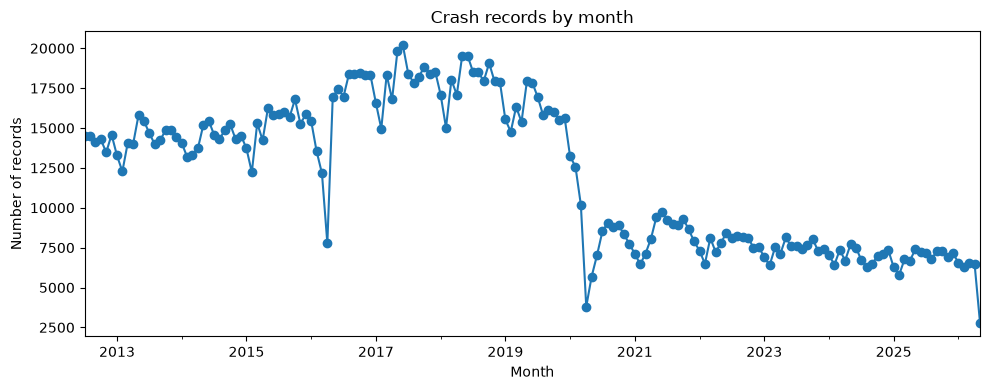

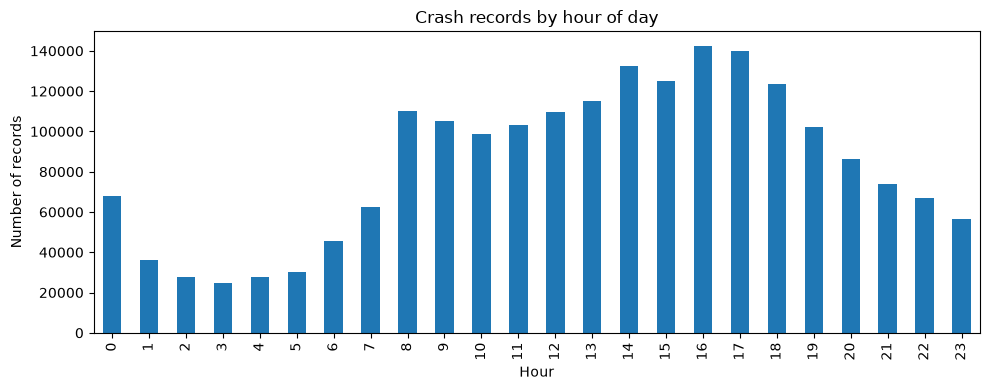

In [10]:
monthly_counts = crashes_clean.set_index("crash_datetime").resample("MS").size()
ax = monthly_counts.plot(marker="o", figsize=(10, 4), title="Crash records by month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

hourly_counts = crashes_clean["crash_hour"].value_counts().sort_index()
ax = hourly_counts.plot(kind="bar", figsize=(10, 4), title="Crash records by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

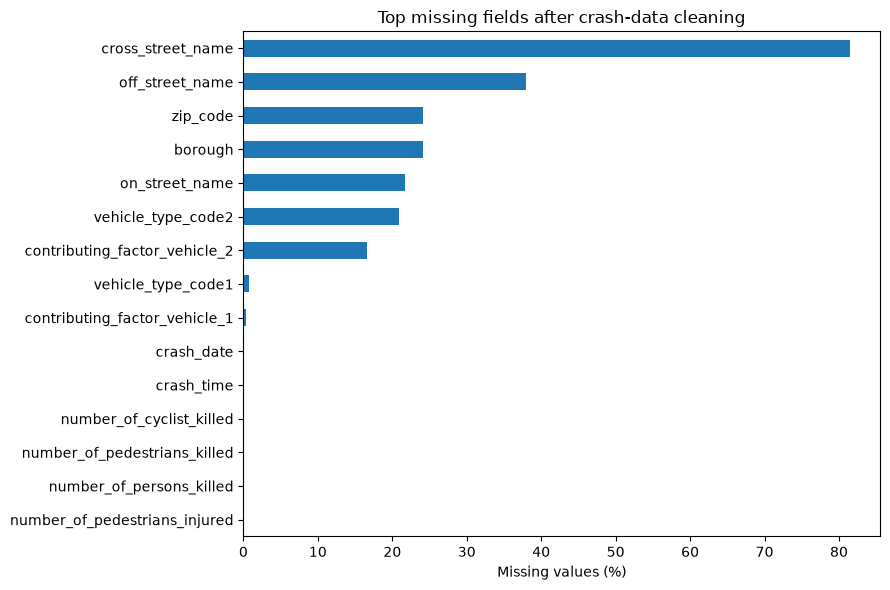

In [11]:
missingness = (
    crashes_clean.isna().mean().mul(100)
    .sort_values(ascending=False).head(15)
)
ax = missingness.sort_values().plot(
    kind="barh", figsize=(9, 6),
    title="Top missing fields after crash-data cleaning",
)
ax.set_xlabel("Missing values (%)")
plt.tight_layout()
plt.show()

### Student checkpoint 1

Before continuing, Joey should be able to explain:

1. Why we save both a raw file and a cleaned file.
2. Why coordinates are validated using a broad NYC bounding box.
3. Why `pedestrian_casualty` is a more accurate name than `pedestrian_involved`.
4. Why these rows are crash events rather than a complete training dataset for predicting whether a crash will happen.

# 5. Download and inspect the OpenStreetMap road network

OSMnx represents roads as a graph. Nodes usually represent intersections or endpoints, while edges represent road segments connecting nodes.

The next cell retrieves the drivable network and keeps useful tags such as lanes, maximum speed, surface, lighting, sidewalk, crossing, and cycleway when OpenStreetMap provides them. A missing tag does not prove that a feature is absent in the real world.

**Citywide note:** with `BOROUGH = "ALL"` the network is built from the union of all five borough boundaries and is much larger than the Manhattan-only graph (tens of thousands of nodes and well over a hundred thousand directed edges). The first download can take several minutes, and the saved GraphML file is large. The next cell keeps *all* connected components for the citywide case. The original `retain_all=False` setting keeps only the single largest component, which could silently drop an entire borough (for example if a bridge falls outside the boundary polygons).

In [12]:
EXTRA_WAY_TAGS = [
    "lanes", "maxspeed", "surface", "lit",
    "sidewalk", "crossing", "cycleway", "width",
]
ox.settings.useful_tags_way = sorted(set(ox.settings.useful_tags_way + EXTRA_WAY_TAGS))
ox.settings.use_cache = True
ox.settings.log_console = False
ox.settings.requests_timeout = 180

if OSM_GRAPH_PATH.exists() and not REFRESH_OSM_DATA:
    street_graph = ox.io.load_graphml(OSM_GRAPH_PATH)
    print(f"Loaded cached street graph: {OSM_GRAPH_PATH}")
else:
    street_graph = ox.graph.graph_from_place(
        PLACE_QUERY,  # a single string, or a list of strings for the citywide case
        network_type="drive",
        simplify=True,
        # Citywide: keep every component so no borough is dropped as "not the largest".
        retain_all=(BOROUGH == "ALL"),
    )
    ox.io.save_graphml(street_graph, OSM_GRAPH_PATH)
    print(f"Downloaded and saved street graph: {OSM_GRAPH_PATH}")

street_count_by_node = ox.stats.count_streets_per_node(street_graph)
nx.set_node_attributes(street_graph, street_count_by_node, "street_count")

print("Street-network nodes:", street_graph.number_of_nodes())
print("Street-network directed edges:", street_graph.number_of_edges())
print("Weakly connected components:", nx.number_weakly_connected_components(street_graph))

Loaded cached street graph: c:\Users\j9936\Desktop\Capstone\noteboooks\data\raw\osm_drive_nyc_all.graphml
Street-network nodes: 55339
Street-network directed edges: 139195
Weakly connected components: 23


## Project the street network into meters

Latitude and longitude are angular coordinates. OSMnx projects the graph into an appropriate local coordinate reference system so distance values are measured in meters. We then convert graph nodes and edges into GeoDataFrames.

In [13]:
street_graph_projected = ox.projection.project_graph(street_graph)
nodes_projected, edges_projected = ox.convert.graph_to_gdfs(
    street_graph_projected, nodes=True, edges=True
)

print("Projected CRS:", street_graph_projected.graph["crs"])
display(nodes_projected.head())
display(edges_projected.head())

Projected CRS: EPSG:32618


,y,x,highway,ref,street_count,junction,railway,geometry
osmid,,,,,,,,
39076461,4.515739e+06,601691.230051,motorway_junction,33,3,NaN,NaN,POINT (601691.23 4515738.523)
274283981,4.516085e+06,602427.817882,NaN,NaN,3,NaN,NaN,POINT (602427.818 4516085.194)
42854803,4.515833e+06,601928.380031,traffic_signals,NaN,3,NaN,NaN,POINT (601928.38 4515832.72)
39076490,4.513128e+06,604906.239252,motorway_junction,31W,3,NaN,NaN,POINT (604906.239 4513128.015)
277672046,4.513126e+06,604950.582059,NaN,NaN,3,NaN,NaN,POINT (604950.582 4513125.945)


osmid        highway lanes  \
u         v          key                                                        
39076461  274283981  0                          25161349       motorway     2   
          42854803   0                          25161578  motorway_link     1   
274283981 3789687872 0    [39084897, 40944009, 40944010]       motorway     3   
42854803  42847609   0                          25161438       tertiary   NaN   
          42816655   0                          25161438       tertiary   NaN   

                          lit maxspeed                               name  \
u         v          key                                                    
39076461  274283981  0    yes   50 mph               Cross Island Parkway   
          42854803   0    NaN      NaN                                NaN   
274283981 3789687872 0    yes   50 mph               Cross Island Parkway   
42854803  42847609   0    NaN      NaN  Cross Island Parkway Service Road   
          42816655   0    NaN      NaN  Cross Island Parkway Service Road   

                          oneway  ref reversed      length  \
u         v          key                                     
39076461  274283981  0      True   CI    False  819.501666   
          42854803   0      True  NaN    False  268.144095   
274283981 3789687872 0      True   CI    False  636.546027   
42854803  42847609   0     False  NaN    False  142.369449   
          42816655   0     False  NaN     True  141.823239   

                                                                   geometry  \
u         v          key                                                      
39076461  274283981  0    LINESTRING (601691.23 4515738.523, 601702.418 ...   
          42854803   0    LINESTRING (601691.23 4515738.523, 601811.421 ...   
274283981 3789687872 0    LINESTRING (602427.818 4516085.194, 602439.751...   
42854803  42847609   0    LINESTRING (601928.38 4515832.72, 601964.997 4...   
          42816655   0    LINESTRING (601928.38 4515832.72, 601919.763 4...   

                         bridge surface sidewalk cycleway access tunnel width  \
u         v          key                                                        
39076461  274283981  0      NaN     NaN      NaN      NaN    NaN    NaN   NaN   
          42854803   0      NaN     NaN      NaN      NaN    NaN    NaN   NaN   
274283981 3789687872 0      yes     NaN      NaN      NaN    NaN    NaN   NaN   
42854803  42847609   0      NaN     NaN      NaN      NaN    NaN    NaN   NaN   
          42816655   0      NaN     NaN      NaN      NaN    NaN    NaN   NaN   

                         junction est_width  
u         v          key                     
39076461  274283981  0        NaN       NaN  
          42854803   0        NaN       NaN  
274283981 3789687872 0        NaN       NaN  
42854803  42847609   0        NaN       NaN  
          42816655   0        NaN       NaN

## Convert crash coordinates into geographic points

A GeoDataFrame adds a geometry column containing actual point objects. We create the points in WGS84 and then project them into the same coordinate system as the road graph.

In [14]:
crash_gdf = gpd.GeoDataFrame(
    crashes_clean.copy(),
    geometry=gpd.points_from_xy(
        crashes_clean["longitude"], crashes_clean["latitude"]
    ),
    crs="EPSG:4326",
)
crash_gdf_projected = crash_gdf.to_crs(street_graph_projected.graph["crs"])

print("Crash GeoDataFrame CRS:", crash_gdf_projected.crs)
display(crash_gdf_projected[["collision_id", "latitude", "longitude", "geometry"]].head())

Crash GeoDataFrame CRS: EPSG:32618


,collision_id,latitude,longitude,geometry
0,37632,40.762127,-73.997387,POINT (584624.397 4512834.864)
1,2999940,40.697753,-73.813916,POINT (600206.856 4505882.056)
2,116256,40.588868,-73.972745,POINT (586929.071 4493626.166)
3,3044659,40.733610,-73.923840,POINT (590870.879 4509742.841)
4,175808,40.677406,-73.983048,POINT (585943.529 4503444.192)


## Match each crash to the nearest street node and edge

The nearest node provides an approximate intersection-complexity feature. The nearest edge provides road-segment attributes. Match distances are retained as quality-control variables because a crash far from its matched road may have an inaccurate coordinate or may occur in an area not represented by the selected network.

With the full citywide table this step matches a very large number of points, which takes noticeably longer than the Manhattan-only run. For the full history it is on the order of two million points. The edge-matching step therefore runs in chunks and prints progress. It is a one-time cost.

In [15]:
x_coordinates = crash_gdf_projected.geometry.x.to_numpy()
y_coordinates = crash_gdf_projected.geometry.y.to_numpy()

nearest_node_ids, node_distances_m = ox.distance.nearest_nodes(
    street_graph_projected, X=x_coordinates, Y=y_coordinates, return_dist=True
)
# Match edges in chunks so memory stays bounded and progress is visible at millions of points.
EDGE_MATCH_CHUNK_ROWS = 200_000
chunk_index_groups = np.array_split(
    np.arange(len(x_coordinates)), max(1, int(np.ceil(len(x_coordinates) / EDGE_MATCH_CHUNK_ROWS)))
)
nearest_edge_ids = []
edge_distance_parts = []
for chunk_number, chunk_indices in enumerate(chunk_index_groups, start=1):
    chunk_edge_ids, chunk_distances = ox.distance.nearest_edges(
        street_graph_projected,
        X=x_coordinates[chunk_indices],
        Y=y_coordinates[chunk_indices],
        return_dist=True,
    )
    nearest_edge_ids.extend(tuple(edge_id) for edge_id in chunk_edge_ids)
    edge_distance_parts.append(np.asarray(chunk_distances))
    print(f"Matched edges: chunk {chunk_number}/{len(chunk_index_groups)}")
edge_distances_m = np.concatenate(edge_distance_parts)

crash_gdf_projected["nearest_osm_node"] = nearest_node_ids
crash_gdf_projected["distance_to_osm_node_m"] = node_distances_m

edge_key_table = pd.DataFrame(
    [tuple(edge_id) for edge_id in nearest_edge_ids],
    columns=["nearest_edge_u", "nearest_edge_v", "nearest_edge_key"],
)
crash_gdf_projected = pd.concat(
    [crash_gdf_projected.reset_index(drop=True), edge_key_table],
    axis=1,
)
crash_gdf_projected["distance_to_osm_edge_m"] = edge_distances_m

print("Median node-match distance (m):", round(float(np.median(node_distances_m)), 2))
print("Median edge-match distance (m):", round(float(np.median(edge_distances_m)), 2))

Matched edges: chunk 1/11
Matched edges: chunk 2/11
Matched edges: chunk 3/11
Matched edges: chunk 4/11
Matched edges: chunk 5/11
Matched edges: chunk 6/11
Matched edges: chunk 7/11
Matched edges: chunk 8/11
Matched edges: chunk 9/11
Matched edges: chunk 10/11
Matched edges: chunk 11/11
Median node-match distance (m): 2.19
Median edge-match distance (m): 0.47


## Join node and road-segment attributes

OpenStreetMap values may be scalars or lists because a simplified edge can combine several original segments. The helper functions convert these values into stable text or numbers without turning missing data into zero.

In [16]:
def normalize_osm_text(value: Any) -> Any:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return pd.NA
    if isinstance(value, (list, tuple, set)):
        unique_values = []
        for item in value:
            item_text = str(item).strip()
            if item_text and item_text not in unique_values:
                unique_values.append(item_text)
        return " | ".join(unique_values) if unique_values else pd.NA
    text = str(value).strip()
    return text if text else pd.NA

def extract_first_number(value: Any) -> float:
    normalized = normalize_osm_text(value)
    if pd.isna(normalized):
        return np.nan
    match = re.search(r"-?\d+(?:\.\d+)?", str(normalized))
    return float(match.group()) if match else np.nan

node_feature_table = (
    nodes_projected[["street_count"]].reset_index()
    .rename(columns={"osmid": "nearest_osm_node"})
)
crash_gdf_projected = crash_gdf_projected.merge(
    node_feature_table,
    on="nearest_osm_node",
    how="left",
    validate="many_to_one",
)

EDGE_SOURCE_COLUMNS = [
    "highway", "name", "lanes", "maxspeed", "oneway", "length",
    "surface", "lit", "sidewalk", "crossing", "cycleway", "width",
]
available_edge_columns = [
    column for column in EDGE_SOURCE_COLUMNS if column in edges_projected.columns
]

edges_for_join = edges_projected.reset_index()[
    ["u", "v", "key"] + available_edge_columns
].rename(columns={
    "u": "nearest_edge_u",
    "v": "nearest_edge_v",
    "key": "nearest_edge_key",
})

crash_gdf_projected = crash_gdf_projected.merge(
    edges_for_join,
    on=["nearest_edge_u", "nearest_edge_v", "nearest_edge_key"],
    how="left",
    validate="many_to_one",
)

for column in [
    "highway", "name", "oneway", "surface",
    "lit", "sidewalk", "crossing", "cycleway",
]:
    if column in crash_gdf_projected.columns:
        crash_gdf_projected[f"osm_{column}"] = (
            crash_gdf_projected[column].map(normalize_osm_text)
        )

if "lanes" in crash_gdf_projected.columns:
    crash_gdf_projected["osm_lanes_numeric"] = (
        crash_gdf_projected["lanes"].map(extract_first_number)
    )
if "maxspeed" in crash_gdf_projected.columns:
    crash_gdf_projected["osm_maxspeed_numeric"] = (
        crash_gdf_projected["maxspeed"].map(extract_first_number)
    )
if "width" in crash_gdf_projected.columns:
    crash_gdf_projected["osm_width_numeric"] = (
        crash_gdf_projected["width"].map(extract_first_number)
    )
if "length" in crash_gdf_projected.columns:
    crash_gdf_projected["osm_edge_length_m"] = pd.to_numeric(
        crash_gdf_projected["length"], errors="coerce"
    )

crash_gdf_projected["osm_intersection_like"] = (
    pd.to_numeric(crash_gdf_projected["street_count"], errors="coerce") >= 3
).astype("Int8")

columns_to_show = [
    "collision_id", "street_count", "osm_intersection_like",
    "osm_highway", "osm_name", "osm_lanes_numeric",
    "osm_maxspeed_numeric", "distance_to_osm_edge_m",
]
display(crash_gdf_projected[[c for c in columns_to_show if c in crash_gdf_projected.columns]].head())

,collision_id,street_count,osm_intersection_like,osm_highway,osm_name,osm_lanes_numeric,osm_maxspeed_numeric,distance_to_osm_edge_m
0,37632,4,1,unclassified,West 44th Street,1.0,25.0,0.598682
1,2999940,4,1,motorway,Van Wyck Expressway,4.0,NaN,0.277361
2,116256,3,1,residential,West 3rd Street,1.0,NaN,0.965532
3,3044659,3,1,motorway,Brooklyn-Queens Expressway,2.0,45.0,0.830156
4,175808,4,1,secondary,Union Street,2.0,NaN,1.434287


## Validate the spatial matching

There is no universal perfect threshold. We start by examining the distribution and flag matches over 50 meters for review. A flag does not automatically mean a row is wrong.

In [17]:
distance_summary = crash_gdf_projected[
    ["distance_to_osm_node_m", "distance_to_osm_edge_m"]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
display(distance_summary)

crash_gdf_projected["osm_match_over_50m"] = (
    crash_gdf_projected["distance_to_osm_edge_m"] > 50
).astype("int8")

print(
    "Percent of crashes matched more than 50 m from an OSM edge:",
    round(100 * crash_gdf_projected["osm_match_over_50m"].mean(), 2),
)

,distance_to_osm_node_m,distance_to_osm_edge_m
count,2.013992e+06,2.013992e+06
mean,1.744487e+01,1.495529e+00
std,3.462306e+01,8.343543e+00
min,0.000000e+00,0.000000e+00
50%,2.188449e+00,4.658298e-01
75%,2.030877e+01,1.145536e+00
90%,5.561349e+01,2.529127e+00
95%,8.237264e+01,5.393483e+00
99%,1.422053e+02,1.682256e+01
max,4.667745e+03,4.624063e+03


Percent of crashes matched more than 50 m from an OSM edge: 0.18


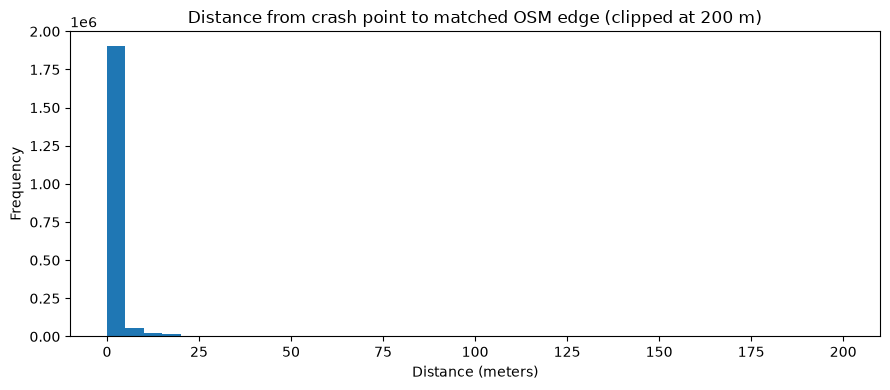

In [18]:
ax = crash_gdf_projected["distance_to_osm_edge_m"].clip(upper=200).plot(
    kind="hist", bins=40, figsize=(9, 4),
    title="Distance from crash point to matched OSM edge (clipped at 200 m)",
)
ax.set_xlabel("Distance (meters)")
plt.tight_layout()
plt.show()

## Save the crash and street-layout table

The file remains at the event level, with one row per crash. It is not yet the intersection-level risk table.

In [19]:
crashes_with_streets = pd.DataFrame(
    crash_gdf_projected.drop(columns="geometry")
)

# OpenStreetMap tags (highway, name, lanes, ...) can hold a Python list in some rows and a
# plain string in others, because simplified edges merge several original road segments.
# Parquet cannot store a column that mixes lists and strings, so convert every such column
# to text. normalize_osm_text() joins list values as "a | b" and leaves missing values missing.
converted_columns = []
for column in crashes_with_streets.columns:
    if crashes_with_streets[column].dtype != "object":
        continue
    sample = crashes_with_streets[column].dropna()
    if sample.empty:
        continue
    # Only touch columns that are not already purely text.
    if not sample.map(lambda value: isinstance(value, str)).all():
        crashes_with_streets[column] = (
            crashes_with_streets[column].map(normalize_osm_text).astype("string")
        )
        converted_columns.append(column)

print("Columns converted to text for parquet:", converted_columns)

crashes_with_streets.to_parquet(STREET_MATCH_PATH, index=False)
print("Saved:", STREET_MATCH_PATH)
print("Shape:", crashes_with_streets.shape)


Columns converted to text for parquet: ['highway', 'name', 'lanes', 'maxspeed', 'surface', 'lit', 'sidewalk', 'cycleway', 'width']
Saved: c:\Users\j9936\Desktop\Capstone\noteboooks\data\interim\crashes_with_street_features.parquet
Shape: (2013992, 65)


### Student checkpoint 2

Joey should now be able to explain:

1. What nodes and edges mean in a street network.
2. Why coordinates were projected before measuring distances.
3. Why distance to the matched edge is retained.
4. Why a missing OpenStreetMap tag does not necessarily mean the real road lacks that feature.
5. Why current OpenStreetMap data may not perfectly represent the street layout at the time of a 2024 crash.

# 6. Download historical hourly weather

For the MVP, we use one representative weather point and join weather by local hour. For the citywide scope that point is Central Park. This is a practical first approximation, not a claim that weather was identical in every borough. Rain bands and snow totals can differ between, say, Staten Island and the Bronx.

Meteostat may return temperature, humidity, precipitation, wind, pressure, and condition fields depending on station and provider availability. The code keeps available fields rather than assuming every variable exists.

**Full-history note:** the download is split into one request per calendar year, retried on errors, and falls back to the nearest weather stations if a point request comes back empty (a known Meteostat behavior). If the source has no real observations at the end of the requested period, which can happen for recent months at US stations, the empty tail is trimmed. Notebook 2 uses the weather file's last date to decide how far the analysis runs, so empty hours must not extend it. Watch the printed warnings: if a whole year is reported missing, weather features for that period will be filled with typical values rather than real observations.

In [20]:
import time as time_module

def normalize_weather_column_name(column: Any) -> str:
    raw_value = getattr(column, "value", column)
    return str(raw_value).split(".")[-1].strip().lower()

def year_chunks(start: datetime, end: datetime) -> list[tuple[datetime, datetime]]:
    """Split [start, end] into calendar-year pieces so no single request is huge."""
    chunks, cursor = [], start
    while cursor <= end:
        chunk_end = min(datetime(cursor.year, 12, 31, 23, 59), end)
        chunks.append((cursor, chunk_end))
        cursor = datetime(cursor.year + 1, 1, 1)
    return chunks

def fetch_weather_chunk(point, chunk_start: datetime, chunk_end: datetime, attempts: int = 3):
    """Fetch one chunk. Retries on errors; if the point request returns nothing
    (a known Meteostat behaviour), falls back to the nearest weather stations.
    Returns a DataFrame, or None if nothing could be retrieved for this period."""
    for attempt in range(1, attempts + 1):
        try:
            frame = ms.hourly(point, chunk_start, chunk_end, timezone="America/New_York").fetch()
            if frame is not None and len(frame) > 0:
                return frame
            stations = ms.stations.nearby(point, limit=4)
            frame = ms.hourly(stations, chunk_start, chunk_end, timezone="America/New_York").fetch()
            if frame is not None and len(frame) > 0:
                print(f"  {chunk_start.year}: point request was empty, used the nearest stations instead")
                return frame
            return None  # a real gap in the source data, not a transient error
        except Exception as error:
            print(f"  {chunk_start.year}: attempt {attempt}/{attempts} failed: {error!r}")
            time_module.sleep(2 * attempt)
    return None

def fetch_hourly_weather(
    latitude: float,
    longitude: float,
    elevation_m: float,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    point = ms.Point(latitude, longitude, elevation_m)
    start = datetime.fromisoformat(start_date)
    end = datetime.fromisoformat(end_date) + timedelta(hours=23, minutes=59)

    frames, missing_years = [], []
    for chunk_start, chunk_end in year_chunks(start, end):
        print(f"Fetching weather {chunk_start.date()} to {chunk_end.date()} ...")
        frame = fetch_weather_chunk(point, chunk_start, chunk_end)
        if frame is None:
            missing_years.append(chunk_start.year)
        else:
            frames.append(frame)

    if not frames:
        raise ValueError(
            "Meteostat returned no weather for any period. Check your internet connection "
            "and the Meteostat package version, then try again."
        )
    if missing_years:
        print("WARNING: no weather could be retrieved for:", missing_years)

    weather_df = pd.concat(frames).reset_index()
    weather_df.columns = [
        normalize_weather_column_name(column)
        for column in weather_df.columns
    ]

    possible_time_columns = [
        column for column in weather_df.columns
        if column in {"time", "datetime", "date"}
    ]
    if not possible_time_columns:
        raise ValueError(
            "Could not identify the Meteostat time column. "
            f"Columns returned: {weather_df.columns.tolist()}"
        )

    time_column = possible_time_columns[0]
    # De-duplicate on the original timestamp (not the local hour, which repeats once a
    # year when clocks fall back), and put the rows in time order.
    weather_df = weather_df.drop_duplicates(subset=[time_column])
    weather_df = weather_df.sort_values(time_column).reset_index(drop=True)

    parsed_time = pd.to_datetime(weather_df[time_column], errors="coerce")
    if getattr(parsed_time.dt, "tz", None) is not None:
        parsed_time = parsed_time.dt.tz_convert("America/New_York").dt.tz_localize(None)
    weather_df["weather_hour"] = parsed_time.dt.floor("h")
    weather_df = weather_df.dropna(subset=["weather_hour"])

    # If the source stops returning real observations before END_DATE (recent months can
    # be missing for US stations), trim the empty tail. Notebook 2 uses the weather file's
    # last date to decide how far the analysis runs, so empty hours must not extend it.
    value_columns = [
        column for column in weather_df.columns
        if column not in {"time", "datetime", "date", "weather_hour"}
    ]
    has_observation = weather_df[value_columns].notna().any(axis=1).to_numpy()
    if has_observation.any():
        last_real_position = int(np.flatnonzero(has_observation)[-1])
        trimmed_rows = len(weather_df) - (last_real_position + 1)
        if trimmed_rows > 0:
            print(f"Trimmed {trimmed_rows:,} trailing hours with no observations "
                  f"(weather data effectively ends {weather_df['weather_hour'].iloc[last_real_position]}).")
        weather_df = weather_df.iloc[: last_real_position + 1]

    return weather_df

if WEATHER_RAW_PATH.exists() and not REFRESH_WEATHER_DATA:
    weather_hourly = pd.read_csv(WEATHER_RAW_PATH)
    weather_hourly["weather_hour"] = pd.to_datetime(
        weather_hourly["weather_hour"], errors="coerce"
    )
    print(f"Loaded cached weather file: {WEATHER_RAW_PATH}")
else:
    weather_hourly = fetch_hourly_weather(
        latitude=WEATHER_LAT,
        longitude=WEATHER_LON,
        elevation_m=WEATHER_ELEVATION_M,
        start_date=START_DATE,
        end_date=END_DATE,
    )
    weather_hourly.to_csv(WEATHER_RAW_PATH, index=False)
    print(f"Downloaded and saved weather file: {WEATHER_RAW_PATH}")

assert not weather_hourly.empty, "Meteostat returned no hourly weather records."

print("Weather shape:", weather_hourly.shape)
print("Weather columns:", weather_hourly.columns.tolist())
display(weather_hourly.head())


Fetching weather 2012-07-01 to 2012-12-31 ...
  2012: point request was empty, used the nearest stations instead
Fetching weather 2013-01-01 to 2013-12-31 ...
  2013: point request was empty, used the nearest stations instead
Fetching weather 2014-01-01 to 2014-12-31 ...
  2014: point request was empty, used the nearest stations instead
Fetching weather 2015-01-01 to 2015-12-31 ...
  2015: point request was empty, used the nearest stations instead
Fetching weather 2016-01-01 to 2016-12-31 ...
  2016: point request was empty, used the nearest stations instead
Fetching weather 2017-01-01 to 2017-12-31 ...
  2017: point request was empty, used the nearest stations instead
Fetching weather 2018-01-01 to 2018-12-31 ...
  2018: point request was empty, used the nearest stations instead
Fetching weather 2019-01-01 to 2019-12-31 ...
  2019: point request was empty, used the nearest stations instead
Fetching weather 2020-01-01 to 2020-12-31 ...
  2020: point request was empty, used the nearest 

,station,time,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco,weather_hour
0,72503,2012-07-01 00:00:00-04:00,28.3,55,0.0,<NA>,280,20.5,<NA>,1008.0,<NA>,2,<NA>,2012-07-01 00:00:00
1,72503,2012-07-01 01:00:00-04:00,27.8,54,0.0,<NA>,280,14.8,<NA>,1008.3,<NA>,0,<NA>,2012-07-01 01:00:00
2,72503,2012-07-01 02:00:00-04:00,27.8,54,0.0,<NA>,280,16.6,<NA>,1008.4,<NA>,0,<NA>,2012-07-01 02:00:00
3,72503,2012-07-01 03:00:00-04:00,27.2,54,0.0,<NA>,300,11.2,<NA>,1008.4,<NA>,0,<NA>,2012-07-01 03:00:00
4,72503,2012-07-01 04:00:00-04:00,26.1,58,0.0,<NA>,290,5.4,<NA>,1008.6,<NA>,0,<NA>,2012-07-01 04:00:00


## Rename common weather fields clearly

Short source names such as `temp`, `rhum`, and `prcp` are renamed when present. A column is not fabricated if Meteostat did not return it.

In [21]:
WEATHER_RENAME_MAP = {
    "temp": "weather_temperature_c",
    "dwpt": "weather_dew_point_c",
    "rhum": "weather_relative_humidity_pct",
    "prcp": "weather_precipitation_mm",
    "snow": "weather_snow_depth_mm",
    "wdir": "weather_wind_direction_deg",
    "wspd": "weather_wind_speed_kmh",
    "wpgt": "weather_peak_wind_gust_kmh",
    "pres": "weather_pressure_hpa",
    "tsun": "weather_sunshine_minutes",
    "coco": "weather_condition_code",
}

weather_hourly = weather_hourly.rename(
    columns={
        old_name: new_name
        for old_name, new_name in WEATHER_RENAME_MAP.items()
        if old_name in weather_hourly.columns
    }
)

weather_feature_columns = [
    column for column in weather_hourly.columns
    if column.startswith("weather_") and column != "weather_hour"
]

print("Weather features available for the merge:")
for column in weather_feature_columns:
    print(" -", column)

Weather features available for the merge:
 - weather_temperature_c
 - weather_relative_humidity_pct
 - weather_precipitation_mm
 - weather_wind_direction_deg
 - weather_wind_speed_kmh
 - weather_peak_wind_gust_kmh
 - weather_pressure_hpa
 - weather_sunshine_minutes
 - weather_condition_code


## Validate weather coverage

We compare the requested hourly range to the returned hours. Weather data can contain gaps because providers do not always report every variable every hour.

In [22]:
expected_hours = pd.date_range(
    start=pd.Timestamp(START_DATE),
    end=pd.Timestamp(END_DATE) + pd.Timedelta(hours=23),
    freq="h",
)

weather_coverage = weather_hourly["weather_hour"].nunique() / len(expected_hours)

print("Unique weather hours:", weather_hourly["weather_hour"].nunique())
print("Expected hours:", len(expected_hours))
print("Hourly timestamp coverage:", f"{weather_coverage:.2%}")

weather_missingness = (
    weather_hourly[weather_feature_columns]
    .isna().mean().mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent").to_frame()
)
display(weather_missingness)

Unique weather hours: 121522
Expected hours: 121536
Hourly timestamp coverage: 99.99%


,missing_percent
weather_sunshine_minutes,100.000000
weather_peak_wind_gust_kmh,98.052429
weather_condition_code,41.781859
weather_precipitation_mm,8.434538
weather_pressure_hpa,1.346926
weather_wind_direction_deg,0.601468
weather_wind_speed_kmh,0.032089
weather_relative_humidity_pct,0.001646
weather_temperature_c,0.000823


# 7. Merge crash, street, and weather data

Each crash has a `weather_hour` rounded down to the nearest hour. The merge is many-to-one: many crashes may occur in one hour, while each weather hour should appear at most once.

In [23]:
weather_for_merge = (
    weather_hourly[["weather_hour"] + weather_feature_columns]
    .drop_duplicates(subset=["weather_hour"])
    .copy()
)

final_event_data = crashes_with_streets.merge(
    weather_for_merge,
    on="weather_hour",
    how="left",
    validate="many_to_one",
)

print("Merged shape:", final_event_data.shape)
print(
    "Rows with at least one weather feature present:",
    final_event_data[weather_feature_columns].notna().any(axis=1).mean(),
)
display(final_event_data.head())

Merged shape: (2013992, 74)
Rows with at least one weather feature present: 0.999996524315886


,crash_date,crash_time,borough,zip_code,latitude,longitude,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,...,osm_match_over_50m,weather_temperature_c,weather_relative_humidity_pct,weather_precipitation_mm,weather_wind_direction_deg,weather_wind_speed_kmh,weather_peak_wind_gust_kmh,weather_pressure_hpa,weather_sunshine_minutes,weather_condition_code
0,2012-07-01,0:05,MANHATTAN,10036,40.762127,-73.997387,11 AVENUE,WEST 44 STREET,0,0,...,0,28.3,55,0.0,280,20.5,<NA>,1008.0,<NA>,<NA>
1,2012-07-01,0:05,<NA>,<NA>,40.697753,-73.813916,<NA>,<NA>,1,0,...,0,28.3,55,0.0,280,20.5,<NA>,1008.0,<NA>,<NA>
2,2012-07-01,0:10,BROOKLYN,11223,40.588868,-73.972745,WEST 3 STREET,BOUCK COURT,0,0,...,0,28.3,55,0.0,280,20.5,<NA>,1008.0,<NA>,<NA>
3,2012-07-01,0:10,<NA>,<NA>,40.733610,-73.923840,<NA>,<NA>,1,0,...,0,28.3,55,0.0,280,20.5,<NA>,1008.0,<NA>,<NA>
4,2012-07-01,0:20,BROOKLYN,11215,40.677406,-73.983048,4 AVENUE,UNION STREET,0,0,...,0,28.3,55,0.0,280,20.5,<NA>,1008.0,<NA>,<NA>


## Final event-level validation

These checks verify that the merge did not duplicate events. We also create a compact missingness report for important crash, street, and weather variables.

In [24]:
assert len(final_event_data) == len(crashes_clean), (
    "The merge changed the number of crash rows."
)
assert final_event_data["collision_id"].is_unique, (
    "Collision IDs are no longer unique after merging."
)

key_quality_columns = [
    "collision_id", "crash_datetime", "latitude", "longitude",
    "street_count", "osm_highway", "osm_lanes_numeric",
    "osm_maxspeed_numeric", "distance_to_osm_edge_m",
] + weather_feature_columns
key_quality_columns = [
    column for column in key_quality_columns
    if column in final_event_data.columns
]

final_missingness = (
    final_event_data[key_quality_columns]
    .isna().mean().mul(100).round(2)
    .rename("missing_percent")
    .sort_values(ascending=False).to_frame()
)
display(final_missingness)

,missing_percent
weather_sunshine_minutes,100.00
weather_peak_wind_gust_kmh,98.79
weather_condition_code,53.63
osm_maxspeed_numeric,51.42
osm_lanes_numeric,43.68
weather_precipitation_mm,7.98
weather_pressure_hpa,1.11
weather_wind_direction_deg,1.03
weather_wind_speed_kmh,0.05
collision_id,0.00


## Save the final Notebook 1 dataset

The output contains one row per reported crash with crash context, matched road attributes, spatial-match quality indicators, and hourly weather. The filename includes `event_level` to prevent confusion with future aggregated modeling tables.

In [25]:
final_event_data.to_parquet(FINAL_DATA_PATH, index=False)

print("Saved final Notebook 1 dataset:")
print(FINAL_DATA_PATH.resolve())
print()
print("Rows:", len(final_event_data))
print("Columns:", len(final_event_data.columns))
print(
    "Memory usage (MB):",
    round(final_event_data.memory_usage(deep=True).sum() / 1_000_000, 2),
)

Saved final Notebook 1 dataset:
C:\Users\j9936\Desktop\Capstone\noteboooks\data\processed\safecross_event_level_dataset_nyc_all.parquet

Rows: 2013992
Columns: 74
Memory usage (MB): 1378.49


# 8. Create a compact data dictionary

A data dictionary explains what important fields mean and where they came from. It should grow as the project adds or transforms variables.

In [26]:
DATA_DICTIONARY = {
    "collision_id": "NYC Open Data identifier for one reported collision event.",
    "crash_datetime": "Combined local crash date and time.",
    "latitude": "Reported crash latitude in decimal degrees.",
    "longitude": "Reported crash longitude in decimal degrees.",
    "any_injury_or_death": "1 when at least one person was reported injured or killed.",
    "fatal_crash": "1 when at least one person was reported killed.",
    "pedestrian_casualty": "1 when at least one pedestrian was reported injured or killed.",
    "cyclist_casualty": "1 when at least one cyclist was reported injured or killed.",
    "nearest_osm_node": "OpenStreetMap graph node nearest to the reported crash point.",
    "street_count": "Approximate number of physical streets meeting at the matched node.",
    "osm_intersection_like": "1 when the matched node has at least three streets.",
    "osm_highway": "OpenStreetMap road-class tag for the nearest edge.",
    "osm_lanes_numeric": "First numeric lane value parsed from the nearest edge's OSM tag.",
    "osm_maxspeed_numeric": "First numeric speed value parsed from the nearest edge's OSM tag.",
    "distance_to_osm_edge_m": "Projected distance in meters from crash point to matched road edge.",
    "osm_match_over_50m": "Quality flag for an edge match farther than 50 meters.",
    "weather_hour": "Crash timestamp rounded down to the local hour for weather merging.",
    "weather_temperature_c": "Hourly air temperature in degrees Celsius, when available.",
    "weather_precipitation_mm": "Hourly precipitation in millimeters, when available.",
    "weather_wind_speed_kmh": "Hourly wind speed in kilometers per hour, when available.",
}

data_dictionary_df = pd.DataFrame([
    {
        "column": column,
        "description": description,
        "present_in_dataset": column in final_event_data.columns,
    }
    for column, description in DATA_DICTIONARY.items()
])
display(data_dictionary_df)

,column,description,present_in_dataset
0,collision_id,NYC Open Data identifier for one reported coll...,True
1,crash_datetime,Combined local crash date and time.,True
2,latitude,Reported crash latitude in decimal degrees.,True
3,longitude,Reported crash longitude in decimal degrees.,True
4,any_injury_or_death,1 when at least one person was reported injure...,True
5,fatal_crash,1 when at least one person was reported killed.,True
6,pedestrian_casualty,1 when at least one pedestrian was reported in...,True
7,cyclist_casualty,1 when at least one cyclist was reported injur...,True
8,nearest_osm_node,OpenStreetMap graph node nearest to the report...,True
9,street_count,Approximate number of physical streets meeting...,True


# 9. Notebook 1 completion checklist

- [ ] The notebook runs from top to bottom.
- [ ] Raw data are saved separately from transformed data.
- [ ] The chosen borough and dates are documented.
- [ ] The clean crash table has unique collision IDs.
- [ ] Spatial matching produces plausible distances.
- [ ] Weather timestamps cover most of the requested period.
- [ ] Missing fields are reported rather than silently replaced.
- [ ] The final file is saved as an event-level dataset.
- [ ] OpenStreetMap attribution appears in the README.
- [ ] Large raw and processed files are excluded from GitHub if appropriate.

### Suggested `.gitignore` entries

```text
data/raw/
data/interim/
data/processed/
cache/
__pycache__/
.ipynb_checkpoints/
```

A small sample dataset may be committed separately if its source and sampling procedure are documented.

# 10. Reflection questions for Joey

1. What is the observational unit in the final table?
2. Why can this table not directly answer, “Will a crash occur at this location and time?”
3. What biases or missingness might exist in police-reported crash records?
4. What does `distance_to_osm_edge_m` tell us?
5. Why should missing OSM lane or speed tags not automatically become zero?
6. What are the limits of using one borough-level weather point?
7. Which fields could leak information if the future target is crash severity?
8. Which road attributes need additional cleaning or categorization?

# 11. Plan for Notebook 2

Notebook 2 should:

1. Choose the prediction unit: intersection, road segment, or location-hour.
2. Define the target clearly.
3. Aggregate crash history without leaking future information.
4. Create exposure or non-crash comparison examples.
5. Perform exploratory data analysis.
6. Split data by time, not only at random.
7. Establish a transparent baseline before advanced models.

### Recommended MVP direction

> **Classify intersections or road segments into higher-risk and lower-risk groups using historical crash frequency or severity, road-layout features, time context, and weather summaries.**

This is more defensible than claiming to predict the exact occurrence of an individual crash from a dataset containing only crash events.